# 📊 P1 — Summarization Benchmark
## prompt-engineering-lab by ChuksForge

**Goal:** Measure and compare summarization quality across:
- **Models:** GPT-4o-mini, GPT-4o, Claude Haiku, Claude Sonnet, Gemini Flash, Gemini Pro
- **Prompts:** 10 strategies from baseline zero-shot → advanced chain-of-thought
- **Metrics:** ROUGE-1/2/L, BERTScore, Flesch-Kincaid, Compression Ratio, LLM-as-Judge

**Output:** Ranked leaderboard + 7 publication-quality charts

---

## 0. Setup & Imports

In [3]:
# Install dependencies (run once)
# !pip install openai anthropic google-generativeai pandas numpy matplotlib bert-score

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

# Set your API keys (or use .env / environment variables)
# os.environ['OPENAI_API_KEY']    = 'sk-...'
# os.environ['ANTHROPIC_API_KEY'] = 'sk-ant-...'
# os.environ['GOOGLE_API_KEY']    = 'AIza...'

print('✅ Setup complete')

✅ Setup complete


## 1. Load & Preview the Dataset

In [4]:
articles = pd.read_csv('data/articles.csv')
print(f'Articles: {len(articles)}')
print(f'Domains: {articles["domain"].unique()}')
print(f'Avg word count: {articles["word_count"].mean():.0f}\n')
articles[['id', 'domain', 'word_count']].style.background_gradient(subset=['word_count'], cmap='Blues')

Articles: 5
Domains: <StringArray>
['technology', 'climate', 'economics', 'health', 'geopolitics']
Length: 5, dtype: str
Avg word count: 194



,id,domain,word_count
0,A01,technology,187
1,A02,climate,210
2,A03,economics,195
3,A04,health,178
4,A05,geopolitics,202


In [5]:
# Preview one article
article = articles[articles['id'] == 'A01'].iloc[0]
print(f'ARTICLE: {article["id"]} ({article["domain"]}, {article["word_count"]} words)')
print('─' * 60)
print(article['text'][:300], '...')
print('\nREFERENCE SUMMARY:')
print(article['reference_summary'])

ARTICLE: A01 (technology, 187 words)
────────────────────────────────────────────────────────────
Artificial intelligence researchers at DeepMind have developed a new algorithm called AlphaFold 3 that can predict the structure of virtually all molecules in the human body with unprecedented accuracy. The system, described in a paper published in Nature, extends the capabilities of its predecessor ...

REFERENCE SUMMARY:
DeepMind's AlphaFold 3 can predict the structure of proteins, DNA, RNA, and drug molecules with high accuracy, potentially speeding up drug discovery. It outperformed existing tools on most benchmarks and is available free to academics, though commercial use requires licensing.


## 2. Preview Prompt Library

In [6]:
from run_experiment import load_prompts
from pathlib import Path

prompts = load_prompts(Path('prompts/prompts.txt'))
print(f'Loaded {len(prompts)} prompts:\n')
for pid, meta in prompts.items():
    preview = meta['template'][:80].replace('\n', ' ')
    print(f'  [{pid}] {meta["strategy"]:35s}  "{preview}..."')

Loaded 9 prompts:

  [P01] zero_shot                            "Summarize the following text:  {{TEXT}}..."
  [P02] zero_shot                            "{{TEXT}}  TL;DR:..."
  [P03] instructed                           "Please provide a concise summary of the following article in 3-5 sentences. Focu..."
  [P04] structured_output                    "Summarize the following text using exactly 3 bullet points. Each bullet should c..."
  [P05] role_prompting + audience_targeting  "You are an expert editor at a major news publication. Your job is to write summa..."
  [P06] structured_extraction                "Analyze the following text and produce a structured summary.  Text: {{TEXT}}  Pr..."
  [P07] chain_of_thought                     "Your task is to produce a high-quality summary of the text below. Work through t..."
  [P08] contrastive_instruction              "Write a summary of the text below.  IMPORTANT RULES: ✓ DO include: main argument..."
  [P09] constrained_length            

In [7]:
from run_experiment import run_experiment

# Quick test — set quick=True to run only 2 articles and 3 prompts
df_quick = run_experiment(
    model_filter=['openai'],       # change to your available provider
    prompt_filter=['P01', 'P05', 'P07'],
    article_filter=['A01'],
    run_llm_judge=False,
    quick=False,
)

print(f'\nShape: {df_quick.shape}')
df_quick[['model', 'prompt_id', 'prompt_strategy', 'rouge1', 'bertscore_f1', 'latency_s', 'summary']].round(3)

20:15:15  INFO      OpenAI client initialized
20:15:15  INFO      [A01] P01 → GPT-4o-mini
20:15:22  INFO      HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
20:17:02  INFO      HTTP Request: HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/config.json "HTTP/1.1 200 OK"
20:17:02  WARNING   Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
20:17:02  INFO      HTTP Request: HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/tokenizer_config.json "HTTP/1.1 200 OK"
20:17:03  INFO      HTTP Request: GET https://huggingface.co/api/models/distilbert-base-uncased/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 307 Temporary Redirect"
20:17:03  INFO      HTTP Request: GET https://huggingface.co/api/models/distilbert/distilbert-base-uncased/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
20:17:12  INFO      [A01] P01 → GPT-4o
20:17:19  INFO      HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
20:17:21  INFO      HTTP Request: HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/config.json "HTTP/1.1 200 OK"
20:17:22  INFO      HTTP Request: HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/tokenizer_config.json "HTTP/1.1 200 OK"
20:17:23  INFO      HTTP Request: GET https://huggingface.co/api/models/distilbert-base-uncased/tree/main/additio

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
20:17:25  INFO      [A01] P05 → GPT-4o-mini
20:17:30  INFO      HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
20:17:30  INFO      HTTP Request: HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/config.json "HTTP/1.1 200 OK"
20:17:30  INFO      HTTP Request: HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/tokenizer_config.json "HTTP/1.1 200 OK"
20:17:31  INFO      HTTP Request: GET https://huggingface.co/api/models/distilbert-base-uncased/tree/main/ad

...

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
20:17:50  INFO      [A01] P07 → GPT-4o
20:17:55  INFO      HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
20:17:56  INFO      HTTP Request: HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/config.json "HTTP/1.1 200 OK"
20:17:56  INFO      HTTP Request: HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/tokenizer_config.json "HTTP/1.1 200 OK"
20:17:56  INFO      HTTP Request: GET https://huggingface.co/api/models/distilbert-base-uncased/tree/main/additio

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
20:17:59  INFO      Results saved → results\results.csv
20:17:59  INFO      Leaderboard → results\leaderboard.csv



Shape: (6, 21)


,model,prompt_id,prompt_strategy,rouge1,bertscore_f1,latency_s,summary
0,GPT-4o-mini,P01,zero_shot,0.295,0.842,7.054,"DeepMind has introduced AlphaFold 3, a new alg..."
1,GPT-4o,P01,zero_shot,0.284,0.838,7.548,DeepMind's researchers have developed AlphaFol...
2,GPT-4o-mini,P05,role_prompting + audience_targeting,0.352,0.857,4.401,DeepMind has created a new algorithm called Al...
3,GPT-4o,P05,role_prompting + audience_targeting,0.359,0.852,4.145,Researchers at DeepMind have created AlphaFold...
4,GPT-4o-mini,P07,chain_of_thought,0.202,0.808,5.774,Step 1 — Identify the main topic in one phrase...
5,GPT-4o,P07,chain_of_thought,0.211,0.810,5.107,Step 1 — Identify the main topic in one phrase...


In [8]:
# ⚠️  This will call all configured APIs.
# Estimated cost: ~$0.10-0.50 depending on models selected.
# Comment out providers you don't want to use in run_experiment.py → MODELS dict.

df_full = run_experiment(
    run_llm_judge=False,  # Set True to enable LLM-as-judge (costs extra tokens)
)

print(f'Total results: {len(df_full)}')
print(f'Models tested: {df_full["model"].unique()}')
print(f'Error rate: {df_full["error"].notna().mean():.1%}')

20:17:59  INFO      OpenAI client initialized
20:18:02  INFO      Anthropic client initialized
C:\Users\HomePC\prompt-engineering-lab\projects\summarization-benchmark\run_experiment.py:154: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  import google.generativeai as genai
20:18:08  INFO      Google client initialized
20:18:08  INFO      [A01] P01 → GPT-4o-mini
20:18:12  INFO      HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
20:18:12  INFO      HTTP Request: HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/config.json "HTTP/1.1 200 OK"
20:18:12  INFO      HTTP Request: HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/tokenizer_config.json "HTTP/1.1 200 OK"
2

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
20:18:15  INFO      [A01] P01 → GPT-4o
20:18:18  INFO      HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
20:18:18  INFO      HTTP Request: HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/config.json "HTTP/1.1 200 OK"
20:18:19  INFO      HTTP Request: HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/tokenizer_config.json "HTTP/1.1 200 OK"
20:18:19  INFO      HTTP Request: GET https://huggingface.co/api/models/distilbert-base-uncased/tree/main/additio

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
20:18:21  INFO      [A01] P01 → Claude Haiku
20:18:24  INFO      HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 200 OK"
20:18:24  INFO      HTTP Request: HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/config.json "HTTP/1.1 200 OK"
20:18:25  INFO      HTTP Request: HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/tokenizer_config.json "HTTP/1.1 200 OK"
20:18:25  INFO      HTTP Request: GET https://huggingface.co/api/models/distilbert-base-uncased/tree/main/additi

...

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
20:50:15  INFO      [A05] P09 → Claude Sonnet 4.6
20:50:18  INFO      HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 200 OK"
20:50:19  INFO      HTTP Request: HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/config.json "HTTP/1.1 200 OK"
20:50:19  INFO      HTTP Request: HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/tokenizer_config.json "HTTP/1.1 200 OK"
20:50:19  INFO      HTTP Request: GET https://huggingface.co/api/models/distilbert-base-uncased/tree/main/a

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
20:50:22  INFO      [A05] P09 → Gemini 1.5 Flash
20:50:22  WARNING   Attempt 1 failed (404 models/gemini-1.5-flash is not found for API version v1beta, or is not supported for generateContent. Call ListModels to see the list of available models and their supported methods.), retrying in 2s
20:50:24  WARNING   Attempt 2 failed (404 models/gemini-1.5-flash is not found for API version v1beta, or is not supported for generateContent. Call ListModels to see the list of available models and their supported methods.), re

Total results: 270
Models tested: <StringArray>
[      'GPT-4o-mini',            'GPT-4o',      'Claude Haiku',
 'Claude Sonnet 4.6',  'Gemini 1.5 Flash',    'Gemini 1.5 Pro']
Length: 6, dtype: str
Error rate: 33.7%


## 5. Explore Results

In [9]:
# Load from saved file (run this cell if re-opening notebook)
df = pd.read_csv('results/results.csv')
df_clean = df[df['error'].isna() | (df['error'] == '')].copy()

print(f'{len(df_clean)} valid results across {df_clean["model"].nunique()} models')

# Summary stats by model
summary = df_clean.groupby('model')[['rouge1', 'rouge2', 'rougeL', 'bertscore_f1', 'latency_s']].mean().round(3)
summary.style.background_gradient(subset=['rouge1', 'bertscore_f1'], cmap='RdYlGn')

179 valid results across 4 models


,rouge1,rouge2,rougeL,bertscore_f1,latency_s
model,,,,,
Claude Haiku,0.429000,0.216000,0.360000,0.864000,3.107000
Claude Sonnet 4.6,0.424000,0.207000,0.351000,0.861000,5.027000
GPT-4o,0.384000,0.169000,0.306000,0.854000,4.086000
GPT-4o-mini,0.384000,0.175000,0.307000,0.854000,4.297000


In [10]:
# Leaderboard — top 15 combinations
lb = pd.read_csv('results/leaderboard.csv')
print('🏆 TOP 15 MODEL × PROMPT COMBINATIONS')
print('─' * 70)
lb.head(15)[['rank', 'model', 'prompt_id', 'prompt_strategy', 'composite_score', 'rouge1', 'bertscore_f1', 'latency_s']].style\
    .background_gradient(subset=['composite_score'], cmap='YlOrRd')

🏆 TOP 15 MODEL × PROMPT COMBINATIONS
──────────────────────────────────────────────────────────────────────


,rank,model,prompt_id,prompt_strategy,composite_score,rouge1,bertscore_f1,latency_s
0,1,Claude Sonnet 4.6,P02,zero_shot,0.648500,0.583100,0.893900,3.924000
1,2,Claude Haiku,P02,zero_shot,0.620000,0.539600,0.884700,2.806800
2,3,GPT-4o-mini,P09,constrained_length,0.582500,0.477800,0.875200,2.898800
3,4,Claude Haiku,P09,constrained_length,0.575900,0.472600,0.866200,1.853400
4,5,GPT-4o,P02,zero_shot,0.564700,0.469000,0.878900,6.294000
5,6,Claude Haiku,P03,instructed,0.564100,0.446800,0.881100,4.738000
6,7,GPT-4o-mini,P02,zero_shot,0.562100,0.453400,0.878400,5.197500
7,8,Claude Sonnet 4.6,P08,contrastive_instruction,0.558000,0.443400,0.875000,3.780400
8,9,Claude Haiku,P01,zero_shot,0.546700,0.434000,0.855800,2.854600
9,10,Claude Sonnet 4.6,P04,structured_output,0.541400,0.414900,0.869300,3.998200


In [11]:
# Best prompt strategy per model
best = lb.loc[lb.groupby('model')['composite_score'].idxmax()]
print('🎯 BEST PROMPT STRATEGY PER MODEL:')
for _, row in best.iterrows():
    print(f'  {row["model"]:25s}  [{row["prompt_id"]}] {row["prompt_strategy"]:35s}  score={row["composite_score"]:.3f}')

🎯 BEST PROMPT STRATEGY PER MODEL:
  Claude Haiku               [P02] zero_shot                            score=0.620
  Claude Sonnet 4.6          [P02] zero_shot                            score=0.648
  GPT-4o                     [P02] zero_shot                            score=0.565
  GPT-4o-mini                [P09] constrained_length                   score=0.583


## 6. Generate All Charts

In [12]:
from visualize import generate_all_charts
generate_all_charts()

Generating charts...
✓ results\chart_leaderboard.png
✓ results\chart_heatmap.png
✓ results\chart_prompt_strategies.png
✓ results\chart_latency_quality.png
✓ results\chart_radar.png
✓ results\charts.png
Charts saved to results


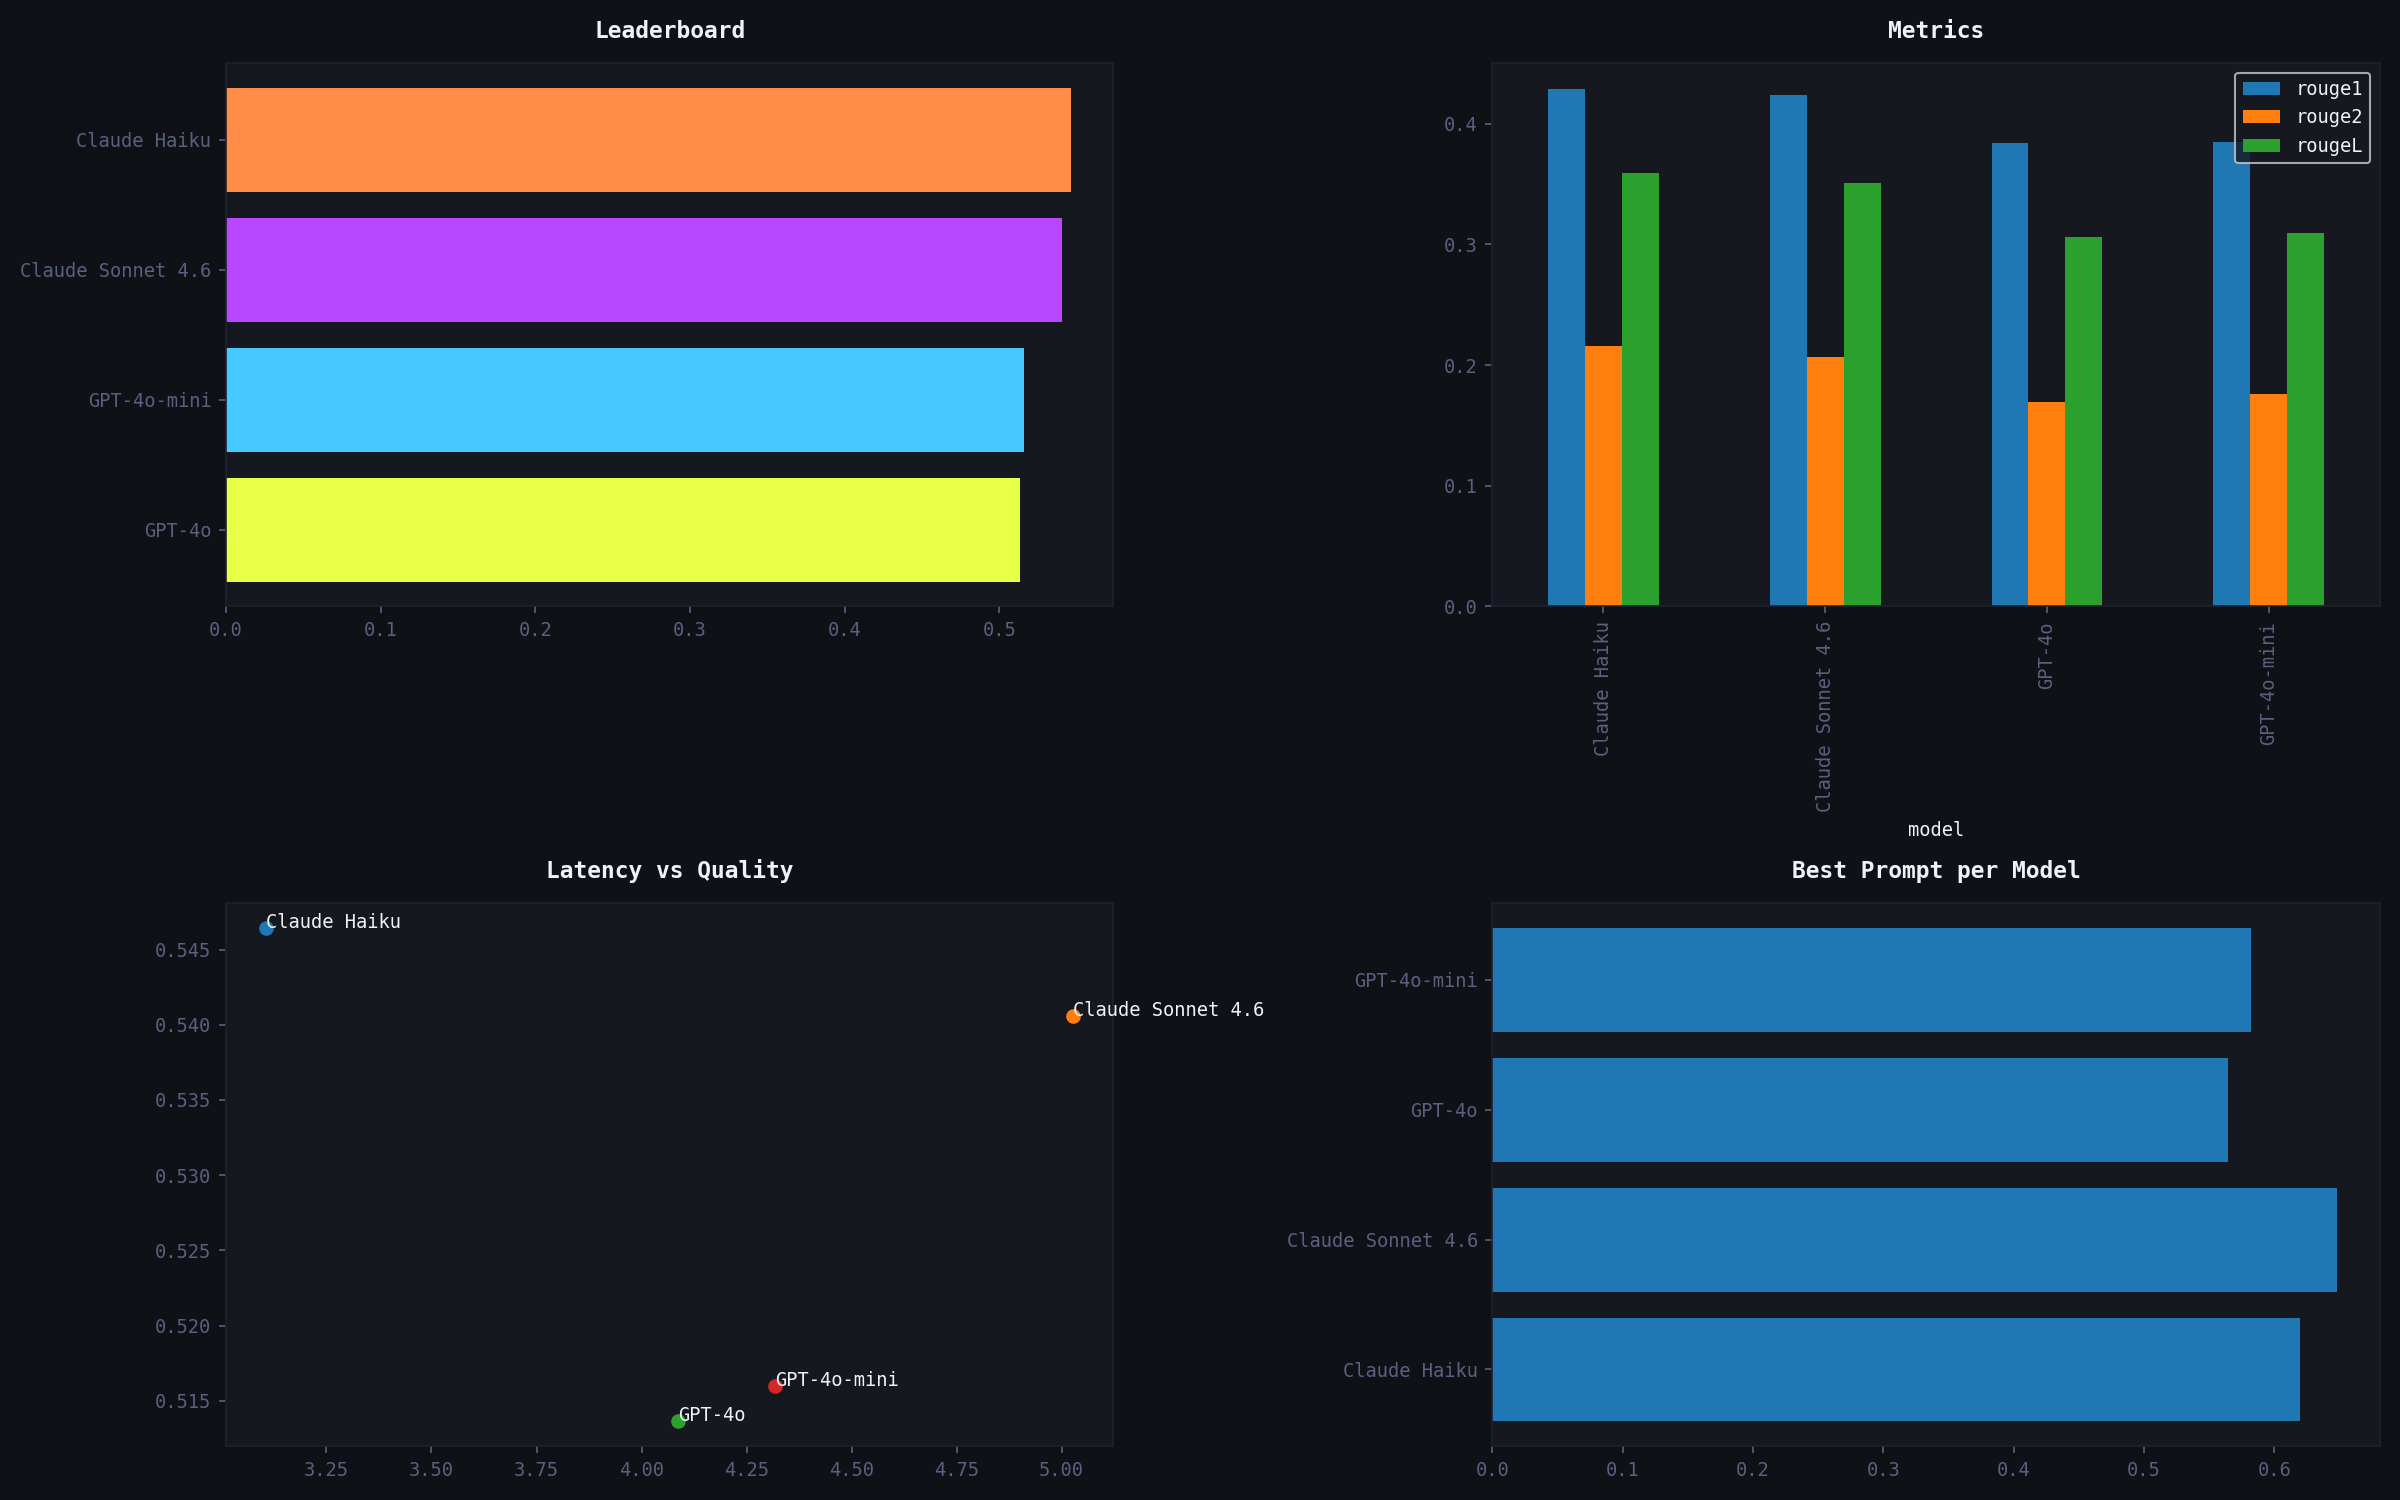

In [13]:
# Display hero chart inline
from IPython.display import Image
Image('results/charts.png')

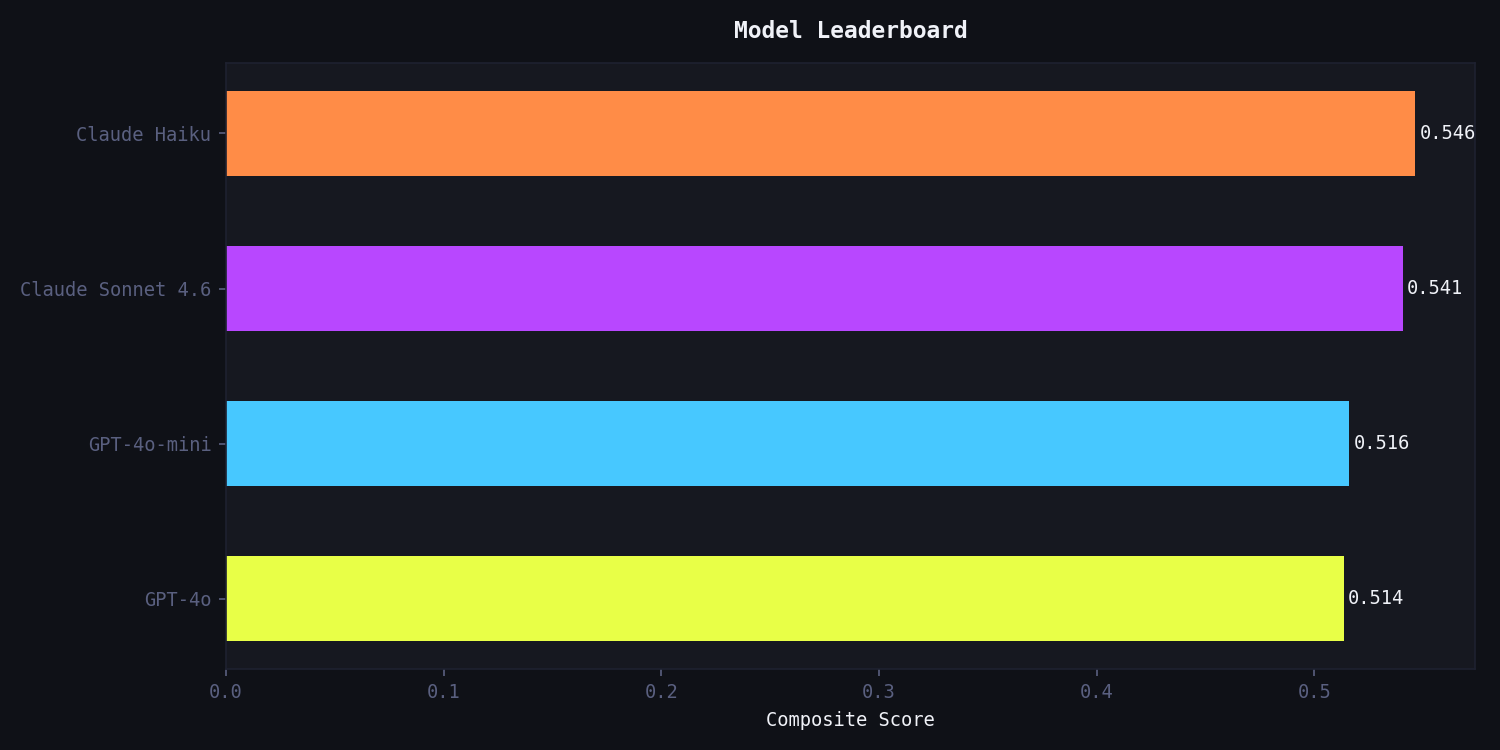

In [14]:
Image('results/chart_leaderboard.png')

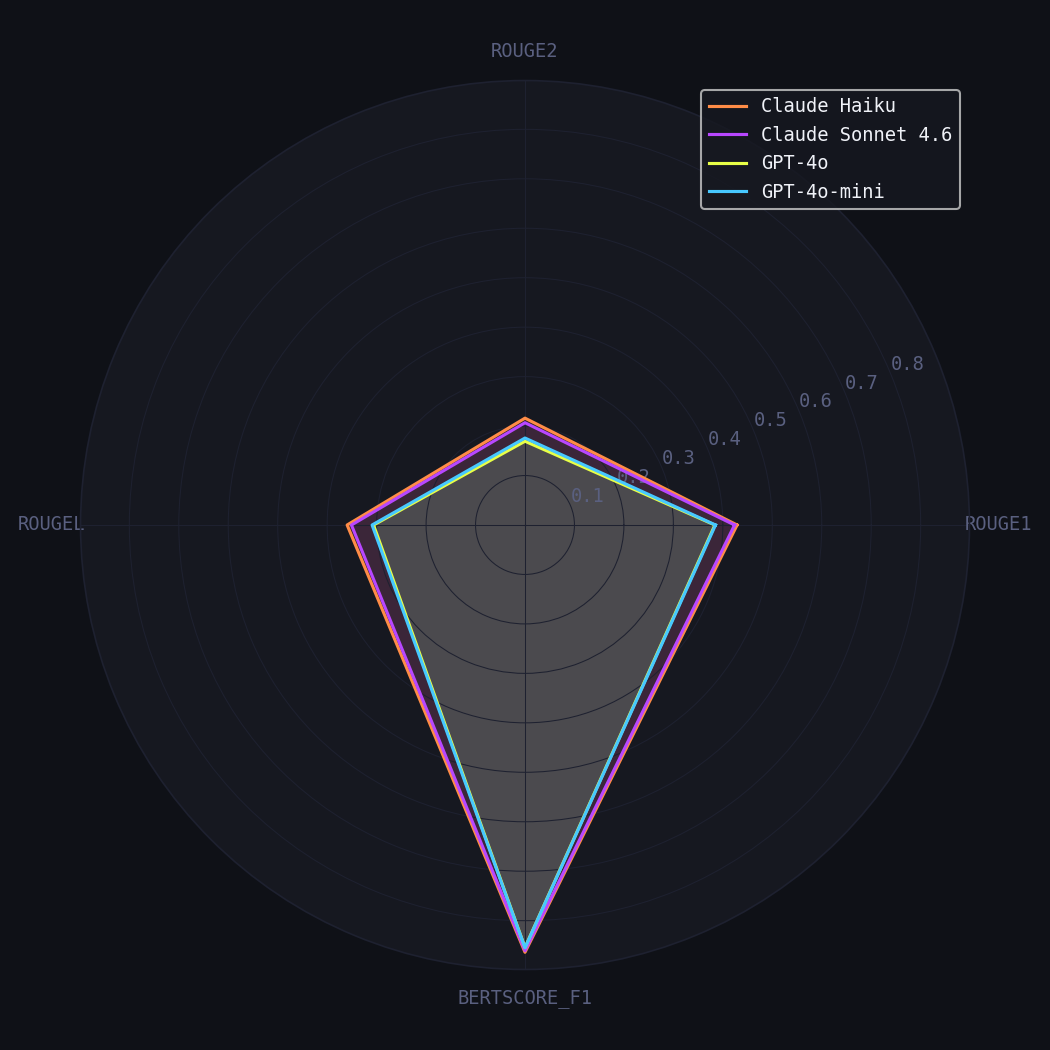

In [15]:
Image('results/chart_radar.png')

## 7. Key Findings Template

In [16]:
# Auto-generate findings narrative
lb = pd.read_csv('results/leaderboard.csv')
best_overall = lb.iloc[0]
model_avg = lb.groupby('model')['composite_score'].mean().sort_values(ascending=False)
best_model = model_avg.index[0]
worst_model = model_avg.index[-1]

# Best vs baseline improvement
baseline = lb[lb['prompt_id'] == 'P01']['composite_score'].mean()
best_score = lb['composite_score'].max()
improvement = (best_score - baseline) / baseline * 100

print('📝 KEY FINDINGS (fill into README):')
print('─' * 60)
print(f'1. Best combination: {best_overall["model"]} × {best_overall["prompt_id"]} '
      f'({best_overall["prompt_strategy"]}) — score: {best_overall["composite_score"]:.3f}')
print(f'2. Best performing model overall: {best_model} (avg: {model_avg[best_model]:.3f})')
print(f'3. Weakest model: {worst_model} (avg: {model_avg[worst_model]:.3f})')
print(f'4. Prompt engineering impact: +{improvement:.1f}% vs zero-shot baseline')
print(f'5. Baseline zero-shot average: {baseline:.3f}')
print(f'6. Best score achieved:        {best_score:.3f}')

📝 KEY FINDINGS (fill into README):
────────────────────────────────────────────────────────────
1. Best combination: Claude Sonnet 4.6 × P02 (zero_shot) — score: 0.648
2. Best performing model overall: Claude Haiku (avg: 0.546)
3. Weakest model: GPT-4o (avg: 0.514)
4. Prompt engineering impact: +24.9% vs zero-shot baseline
5. Baseline zero-shot average: 0.519
6. Best score achieved:        0.648


## 8. Export Report

The notebook itself IS the report. For portfolio purposes:
1. Run all cells
2. `File → Export → HTML` for a shareable version
3. Or use `jupyter nbconvert --to html experiment.ipynb`

All artifacts are in `results/`:
- `results.csv` — raw data, every run
- `leaderboard.csv` — aggregated rankings
- `charts.png` — hero chart (4-panel overview)
- `chart_*.png` — individual charts for README